#Importing Libraries

In [2]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

from scipy import stats
from scipy.signal import periodogram

import statsmodels.api as sm

from google.colab import drive

#Mounting Google Drive
Google Drive is mounted so that the NASA GISTEMP and NOAA sunspot datasets stored in the Drive can be accessed directly from the Colab environment.

In [3]:
drive.mount('/content/drive')

Mounted at /content/drive


#Creating Project Directories

In [4]:
folders = [
    "data/raw",
    "data/processed",
    "figures",
    "results"
]

for folder in folders:
    os.makedirs(folder, exist_ok=True)

print("Project folders created.")

os.makedirs("data/processed", exist_ok=True)
os.makedirs("figures", exist_ok=True)
os.makedirs("results", exist_ok=True)

print("Output directories created.")

Project folders created.
Output directories created.


#Loading NASA GISTEMP Data

A temperature anomaly represents the difference between the observed temperature and a reference climatological temperature:

$$ T_{\text{anomaly}} = T_{\text{observed}} - T_{\text{reference}} $$

A positive anomaly indicates temperatures above the reference average, while a negative anomaly indicates temperatures below it.

In [5]:
temp = '/content/drive/MyDrive/gistemp_global_monthly.csv'
df = pd.read_csv(temp)

df.head()

,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec,J-D,D-N,DJF,MAM,JJA,SON
0,1880,-0.19,-0.26,-0.10,-0.17,-0.11,-0.22,-0.19,-0.11,-0.15,-0.24,-0.23,-0.18,-0.18,***,***,-0.13,-0.17,-0.21
1,1881,-0.20,-0.15,0.03,0.05,0.05,-0.19,0.00,-0.04,-0.16,-0.22,-0.19,-0.08,-0.09,-0.1,-0.18,0.04,-0.08,-0.19
2,1882,0.16,0.13,0.04,-0.16,-0.14,-0.23,-0.17,-0.08,-0.15,-0.24,-0.17,-0.37,-0.12,-0.09,0.07,-0.09,-0.16,-0.19
3,1883,-0.30,-0.37,-0.13,-0.19,-0.18,-0.07,-0.08,-0.14,-0.22,-0.11,-0.25,-0.12,-0.18,-0.2,-0.34,-0.16,-0.10,-0.19
4,1884,-0.13,-0.08,-0.36,-0.40,-0.34,-0.35,-0.31,-0.28,-0.27,-0.25,-0.34,-0.31,-0.29,-0.27,-0.11,-0.37,-0.31,-0.29


#Loading NOAA Sunspot Data

Sunspots are temporary spots on the Sun's surface that are darker than the surrounding area. They are regions of reduced surface temperature caused by concentrations of magnetic flux that inhibit convection.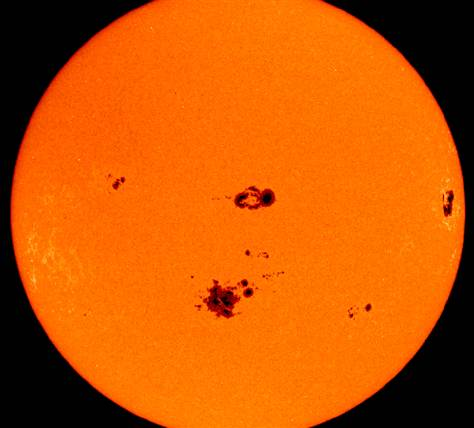

In [6]:
sun = '/content/drive/MyDrive/sunspot_monthly.csv'
df = pd.read_csv(sun)
print("NOAA Sunspot:")
df.head()

NOAA Sunspot:


,Year,Jan,Feb,Mar,Apr,May,Jun,Jul,Aug,Sep,Oct,Nov,Dec
0,1749.0,96.7,104.3,116.7,92.8,141.7,139.2,158.0,110.5,126.5,125.8,264.3,142.0
1,1750.0,122.2,126.5,148.7,147.2,150.0,166.7,142.3,171.7,152.0,109.5,105.5,125.7
2,1751.0,116.7,72.5,75.5,94.0,101.2,84.5,110.5,99.7,39.2,38.7,47.5,73.3
3,1752.0,58.3,83.3,118.3,98.8,99.5,66.0,130.7,48.8,45.2,77.7,62.7,66.7
4,1753.0,73.3,53.3,76.2,63.3,60.0,52.8,36.7,65.0,46.7,41.7,33.3,11.2


In [7]:
temp = pd.read_csv("/content/drive/MyDrive/gistemp_global_monthly.csv")
sun = pd.read_csv("/content/drive/MyDrive/sunspot_monthly.csv")
print(sun.columns.tolist())
print(temp.columns.tolist())

['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
['Year', 'Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec', 'J-D', 'D-N', 'DJF', 'MAM', 'JJA', 'SON']


#Standardizing Monthly Time Information

This conversion is necessary because the datasets store months as column names such as Jan, Feb, and Mar, while time-series operations require an actual date representation.

In [8]:
months = [
    "Jan", "Feb", "Mar", "Apr", "May", "Jun",
    "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"
]

month_numbers = {
    "Jan": 1,
    "Feb": 2,
    "Mar": 3,
    "Apr": 4,
    "May": 5,
    "Jun": 6,
    "Jul": 7,
    "Aug": 8,
    "Sep": 9,
    "Oct": 10,
    "Nov": 11,
    "Dec": 12
}


#Converting Sunspot Data to Monthly Time-Series Format

In [9]:

sunspot = sun.melt(
    id_vars="Year",
    value_vars=months,
    var_name="Month",
    value_name="Sunspot_Number"
)

sunspot["Month_Number"] = sunspot["Month"].map(month_numbers)

sunspot["Date"] = pd.to_datetime(
    dict(
        year=sunspot["Year"],
        month=sunspot["Month_Number"],
        day=1
    )
)
sunspot_monthly = sunspot[
    ["Date", "Sunspot_Number"]
]

print("NOAA Sunspot:")
display(sunspot_monthly.head(15))

NOAA Sunspot:


,Date,Sunspot_Number
0,1749-01-01,96.7
1,1750-01-01,122.2
2,1751-01-01,116.7
3,1752-01-01,58.3
4,1753-01-01,73.3
5,1754-01-01,0.0
6,1755-01-01,17.0
7,1756-01-01,20.8
8,1757-01-01,23.5
9,1758-01-01,62.7


#Converting GISTEMP Data to Monthly Time-Series Format

In [10]:
gistemp = temp.melt(
    id_vars="Year",
    value_vars=months,
    var_name="Month",
    value_name="Temperature_Anomaly"
)

gistemp["Month_Number"] = gistemp["Month"].map(month_numbers)

gistemp["Date"] = pd.to_datetime(
    dict(
        year=gistemp["Year"],
        month=gistemp["Month_Number"],
        day=1
    )
)

gistemp_monthly = gistemp[
    ["Date", "Temperature_Anomaly"]
]

print("\nNASA GISTEMP:")
display(gistemp_monthly.head(15))


NASA GISTEMP:


,Date,Temperature_Anomaly
0,1880-01-01,-0.19
1,1881-01-01,-0.2
2,1882-01-01,0.16
3,1883-01-01,-0.3
4,1884-01-01,-0.13
5,1885-01-01,-0.59
6,1886-01-01,-0.45
7,1887-01-01,-0.72
8,1888-01-01,-0.34
9,1889-01-01,-0.1


#Merging Sunspot data and global temperature anomaly Data

In [11]:
df = pd.merge(
    sunspot,
    gistemp,
    on="Date",
    how="inner"
)

df = df.sort_values("Date").reset_index(drop=True)

display(df.head(15))

,Year_x,Month_x,Sunspot_Number,Month_Number_x,Date,Year_y,Month_y,Temperature_Anomaly,Month_Number_y
0,1880.0,Jan,40.1,1,1880-01-01,1880,Jan,-0.19,1
1,1880.0,Feb,45.4,2,1880-02-01,1880,Feb,-0.26,2
2,1880.0,Mar,32.1,3,1880-03-01,1880,Mar,-0.1,3
3,1880.0,Apr,32.4,4,1880-04-01,1880,Apr,-0.17,4
4,1880.0,May,39.1,5,1880-05-01,1880,May,-0.11,5
5,1880.0,Jun,56.9,6,1880-06-01,1880,Jun,-0.22,6
6,1880.0,Jul,36.5,7,1880-07-01,1880,Jul,-0.19,7
7,1880.0,Aug,80.3,8,1880-08-01,1880,Aug,-0.11,8
8,1880.0,Sep,110.1,9,1880-09-01,1880,Sep,-0.15,9
9,1880.0,Oct,71.7,10,1880-10-01,1880,Oct,-0.24,10


#Necesscery data cleaning and Processing

In [12]:
print("Number of rows:", len(df))
print("Starting date:", df["Date"].min())
print("Ending date:", df["Date"].max())

Number of rows: 1764
Starting date: 1880-01-01 00:00:00
Ending date: 2026-12-01 00:00:00


In [13]:
print(df.isna().sum())

Year_x                 0
Month_x                0
Sunspot_Number         0
Month_Number_x         0
Date                   0
Year_y                 0
Month_y                0
Temperature_Anomaly    0
Month_Number_y         0
dtype: int64


In [14]:
df = df[
    ["Date", "Sunspot_Number", "Temperature_Anomaly"]
].copy()

display(df.head(15))

,Date,Sunspot_Number,Temperature_Anomaly
0,1880-01-01,40.1,-0.19
1,1880-02-01,45.4,-0.26
2,1880-03-01,32.1,-0.1
3,1880-04-01,32.4,-0.17
4,1880-05-01,39.1,-0.11
5,1880-06-01,56.9,-0.22
6,1880-07-01,36.5,-0.19
7,1880-08-01,80.3,-0.11
8,1880-09-01,110.1,-0.15
9,1880-10-01,71.7,-0.24


In [15]:
print(df.dtypes)

Date                   datetime64[ns]
Sunspot_Number                float64
Temperature_Anomaly            object
dtype: object


In [16]:
data = df[
    (df["Date"] >= "1950-01-01") &
    (df["Date"] <= "2024-12-01")
].copy()

data = data.reset_index(drop=True)

print("Study period:")
print(data["Date"].min(), "to", data["Date"].max())

print("\nNumber of observations:")
print(len(data))

Study period:
1950-01-01 00:00:00 to 2024-12-01 00:00:00

Number of observations:
900


#Saving Processed Dataset

In [17]:
data.to_csv(
    "data/processed/solar_temperature_1950_2024.csv",
    index=False
)

print("Processed dataset saved.")

Processed dataset saved.


#Monthly Sunspot Activity Plot

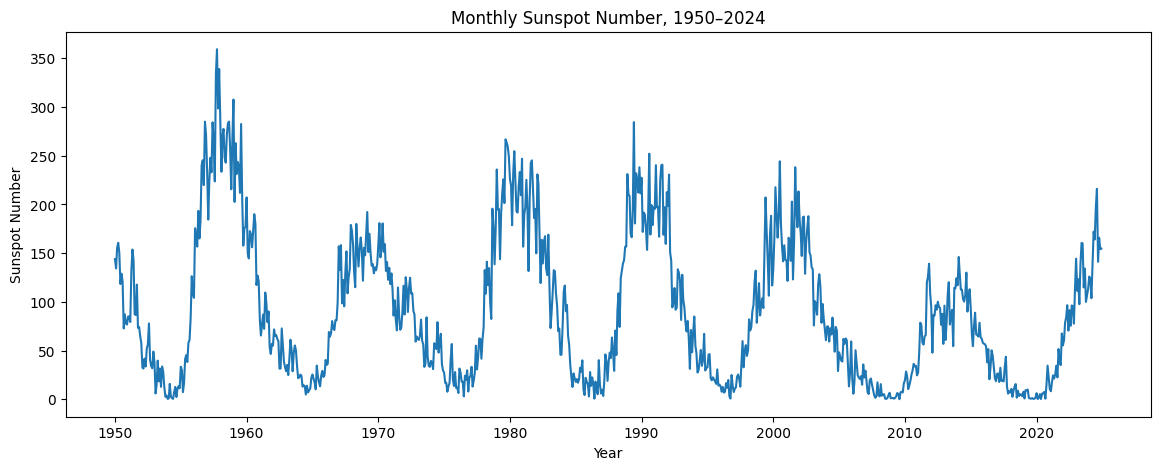

In [18]:
plt.figure(figsize=(14, 5))

plt.plot(
    data["Date"],
    data["Sunspot_Number"]
)

plt.xlabel("Year")
plt.ylabel("Sunspot Number")
plt.title(
    "Monthly Sunspot Number, 1950–2024"
)
plt.show()

#Global Temperature Anomalies Plot

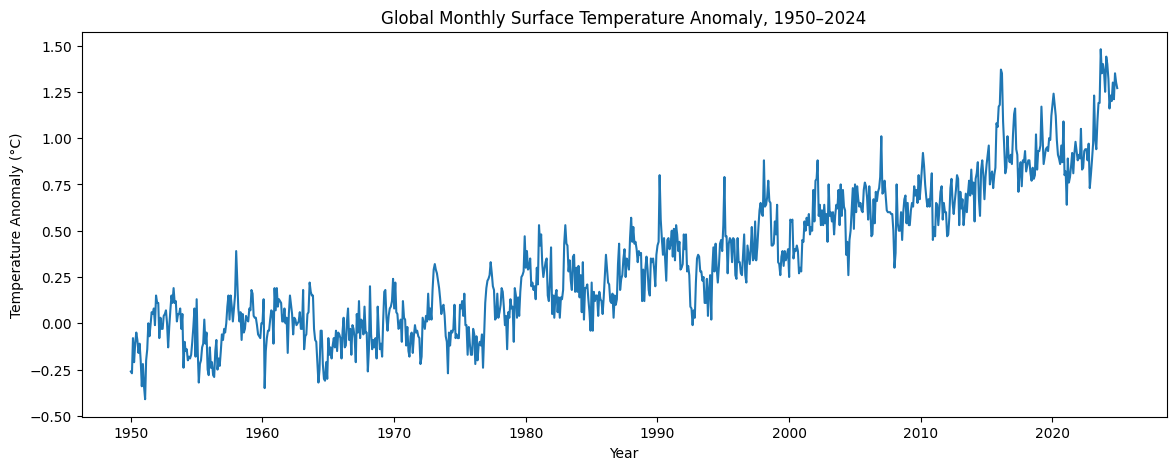

In [19]:
plt.figure(figsize=(14, 5))

plt.plot(
    data["Date"],
    data["Temperature_Anomaly"]
)

plt.xlabel("Year")
plt.ylabel("Temperature Anomaly (°C)")
plt.title(
    "Global Monthly Surface Temperature Anomaly, 1950–2024"
)

plt.show()

#Converting Variables to Numeric Format

In [20]:
data = data.copy()

data["Temperature_Anomaly"] = pd.to_numeric(
    data["Temperature_Anomaly"],
    errors="coerce"
)

data["Sunspot_Number"] = pd.to_numeric(
    data["Sunspot_Number"],
    errors="coerce"
)

print(data.dtypes)

print("\nMissing values:")
print(data[["Temperature_Anomaly", "Sunspot_Number"]].isna().sum())

Date                   datetime64[ns]
Sunspot_Number                float64
Temperature_Anomaly           float64
dtype: object

Missing values:
Temperature_Anomaly    0
Sunspot_Number         0
dtype: int64


#Removing Seasonal Temperature Effects

For month \(m\):

$$ \bar{T}_m = \frac{1}{N_m} \sum_{i=1}^{N_m}T_{i,m} $$

The deseasonalized temperature is:

$$ T'_{i,m}=T_{i,m}-\bar{T}_m $$

This removes the average seasonal pattern so that the analysis focuses on deviations from the typical temperature for each month.

In [21]:
data["Month"] = data["Date"].dt.month

monthly_climatology = (
    data.groupby("Month")["Temperature_Anomaly"]
        .transform("mean")
)

data["Temperature_Deseasonalized"] = (
    data["Temperature_Anomaly"]
    - monthly_climatology
)

display(
    data[
        [
            "Date",
            "Temperature_Anomaly",
            "Temperature_Deseasonalized"
        ]
    ].head(15)
)

,Date,Temperature_Anomaly,Temperature_Deseasonalized
0,1950-01-01,-0.26,-0.604933
1,1950-02-01,-0.27,-0.625600
2,1950-03-01,-0.08,-0.461467
3,1950-04-01,-0.21,-0.544933
4,1950-05-01,-0.11,-0.427467
5,1950-06-01,-0.05,-0.366133
6,1950-07-01,-0.09,-0.406400
7,1950-08-01,-0.16,-0.482667
8,1950-09-01,-0.11,-0.432267
9,1950-10-01,-0.20,-0.536000


#Removing Long-Term Linear Trends

The fitted linear model is:

$$ y_t = \beta_0+\beta_1t+\epsilon_t $$

where:

$y_t$ = observed value, $t$ = time, $\beta_0$ = intercept, $\beta_1$ = linear trend, $\epsilon_t$ = residual.


The detrended series is:

$$ y_t^{*}=y_t-(\beta_0+\beta_1t) $$

This is important because two variables can appear correlated simply because both change systematically with time.

In [22]:
def detrend_series(series):

    values = np.asarray(series, dtype=float)

    x = np.arange(len(values))

    mask = np.isfinite(values)

    result = np.full(len(values), np.nan)

    slope, intercept = np.polyfit(
        x[mask],
        values[mask],
        1
    )

    result[mask] = (
        values[mask]
        - (slope * x[mask] + intercept)
    )

    return result


data["Sunspot_Detrended"] = detrend_series(
    data["Sunspot_Number"]
)

data["Temperature_Detrended"] = detrend_series(
    data["Temperature_Anomaly"]
)

#Pearson Correlation of Detrended Data

The Pearson correlation coefficient is:

$$ r= \frac{ \sum_{i=1}^{n}(X_i-\bar X)(Y_i-\bar Y) }{ \sqrt{ \sum_{i=1}^{n}(X_i-\bar X)^2 \sum_{i=1}^{n}(Y_i-\bar Y)^2 }} $$

Interpretation:

\(r=+1): Perfect positive linear relationship

\(r=0\): No linear relationship

\(r=-1\): Perfect negative linear relationship

The p-value tests the null hypothesis:

$H_0$:ρ=0

In [36]:
detrended = data[
    [
        "Sunspot_Detrended",
        "Temperature_Detrended"
    ]
].dropna()

r_detrended, p_detrended = stats.pearsonr(
    detrended["Sunspot_Detrended"],
    detrended["Temperature_Detrended"]
)


print("DETRENDED PEARSON CORRELATION")


print(f"\nDetrended Pearson r = {r_detrended:.6f}")
print(f"Ordinary p-value    = {p_detrended:.6e}")
print(f"N                   = {len(detrended)}")

DETRENDED PEARSON CORRELATION

Detrended Pearson r = 0.127095
Ordinary p-value    = 1.318096e-04
N                   = 900


#12-Month Moving Average Smoothing

A 12-month moving average is calculated for both solar activity and temperature.

For a variable \(X\), the 12-month moving average is:

$$ MA_t= \frac{1}{12} \sum_{i=0}^{11}X_{t-i} $$

This reduces short-term monthly fluctuations and makes longer-term variations easier to visualize.

In [24]:
data["Sunspot_12M"] = (
    data["Sunspot_Number"]
    .rolling(window=12)
    .mean()
)

data["Temperature_12M"] = (
    data["Temperature_Anomaly"]
    .rolling(window=12)
    .mean()
)

display(
    data[
        [
            "Date",
            "Sunspot_12M",
            "Temperature_12M"
        ]
    ].head(20)
)

,Date,Sunspot_12M,Temperature_12M
0,1950-01-01,NaN,NaN
1,1950-02-01,NaN,NaN
2,1950-03-01,NaN,NaN
3,1950-04-01,NaN,NaN
4,1950-05-01,NaN,NaN
5,1950-06-01,NaN,NaN
6,1950-07-01,NaN,NaN
7,1950-08-01,NaN,NaN
8,1950-09-01,NaN,NaN
9,1950-10-01,NaN,NaN


#Plotting Smoothed Solar Activity

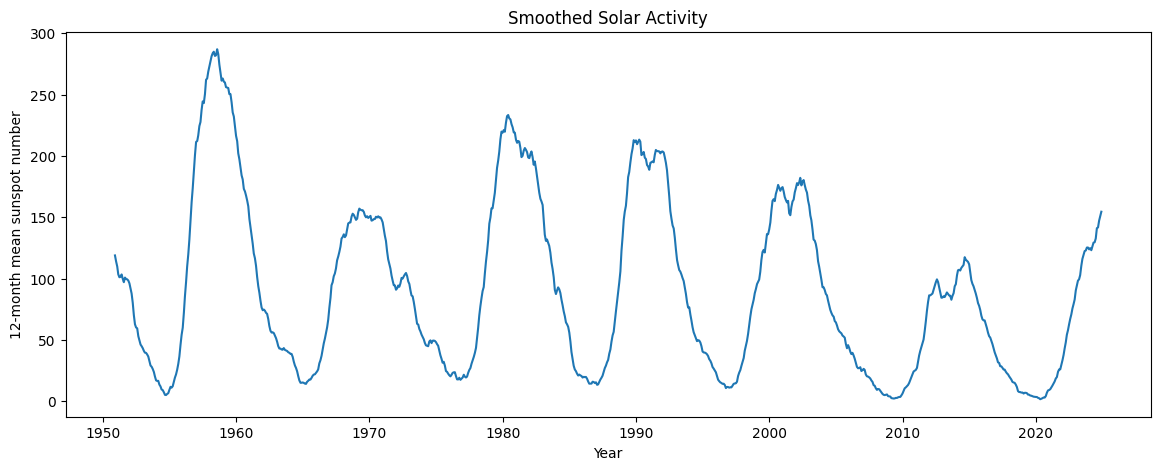

In [25]:
plt.figure(figsize=(14, 5))

plt.plot(
    data["Date"],
    data["Sunspot_12M"]
)

plt.xlabel("Year")
plt.ylabel("12-month mean sunspot number")
plt.title(
    "Smoothed Solar Activity"
)

plt.show()

#Plotting Smoothed Temperature

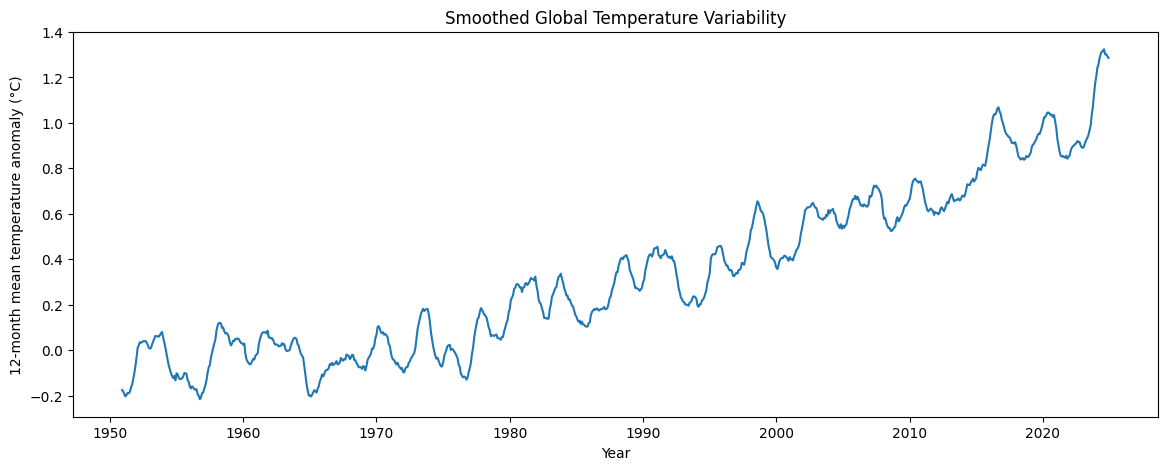

In [26]:
plt.figure(figsize=(14, 5))

plt.plot(
    data["Date"],
    data["Temperature_12M"]
)

plt.xlabel("Year")
plt.ylabel("12-month mean temperature anomaly (°C)")
plt.title(
    "Smoothed Global Temperature Variability"
)

plt.show()

#Correlation of 12-Month Smoothed Series

Pearson correlation is calculated between the 12-month moving averages.

The same correlation equation is used:

$$ r= \frac{\operatorname{Cov}(X,Y)} {\sigma_X\sigma_Y} $$

where \(X\) is smoothed solar activity and \(Y\) is smoothed temperature.

In [35]:
smooth = data[
    [
        "Sunspot_12M",
        "Temperature_12M"
    ]
].dropna()

r_smooth, p_smooth = stats.pearsonr(
    smooth["Sunspot_12M"],
    smooth["Temperature_12M"]
)


print("12-MONTH SMOOTHED CORRELATION")


print(f"\nPearson r = {r_smooth:.6f}")
print(f"p-value   = {p_smooth:.6e}")
print(f"N         = {len(smooth)}")

12-MONTH SMOOTHED CORRELATION

Pearson r = -0.184091
p-value   = 3.230399e-08
N         = 889


#Z-Score Standardization

The Z-score is:

$$ Z_i= \frac{X_i-\bar X}{s} $$

where:

$X_i$ = observation,

$\bar X$ = sample mean,

$s$ = sample standard deviation.

In [28]:
data["Sunspot_Z"] = (
    data["Sunspot_12M"]
    - data["Sunspot_12M"].mean()
) / data["Sunspot_12M"].std()

data["Temperature_Z"] = (
    data["Temperature_12M"]
    - data["Temperature_12M"].mean()
) / data["Temperature_12M"].std()

display(
    data[
        [
            "Date",
            "Sunspot_Z",
            "Temperature_Z"
        ]
    ].head(20)
)

,Date,Sunspot_Z,Temperature_Z
0,1950-01-01,NaN,NaN
1,1950-02-01,NaN,NaN
2,1950-03-01,NaN,NaN
3,1950-04-01,NaN,NaN
4,1950-05-01,NaN,NaN
5,1950-06-01,NaN,NaN
6,1950-07-01,NaN,NaN
7,1950-08-01,NaN,NaN
8,1950-09-01,NaN,NaN
9,1950-10-01,NaN,NaN


#Plotting Standardized Solar and Temperature Series

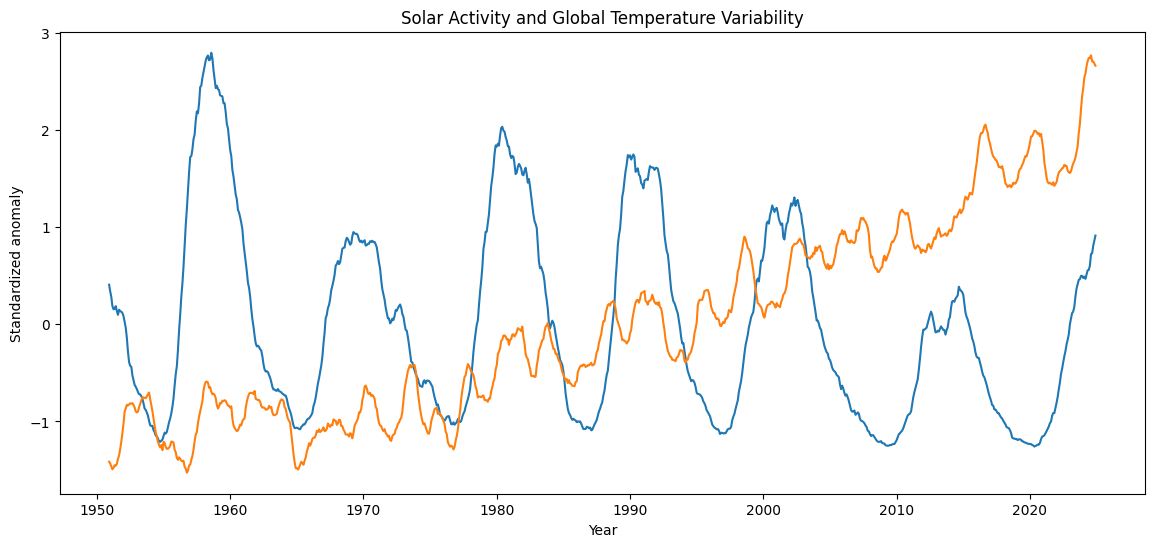

In [29]:
plt.figure(figsize=(14, 6))

plt.plot(
    data["Date"],
    data["Sunspot_Z"],
    label="Solar activity"
)

plt.plot(
    data["Date"],
    data["Temperature_Z"],
    label="Temperature"
)

plt.xlabel("Year")
plt.ylabel("Standardized anomaly")
plt.title(
    "Solar Activity and Global Temperature Variability"

)

plt.show()

#Pearson Correlation of Standardized Variables

In [30]:
analysis_data = data[
    ["Sunspot_Z", "Temperature_Z"]
].dropna()

r, p = stats.pearsonr(
    analysis_data["Sunspot_Z"],
    analysis_data["Temperature_Z"]
)

print("Pearson correlation:", r)
print("p-value:", p)

Pearson correlation: -0.18409096612185571
p-value: 3.230398941026766e-08


#Scatter Plot and Linear Regression

A simple linear regression is fitted:

$$ Y=\beta_0+\beta_1X+\epsilon $$

where:

$X$ = solar activity,
$Y$ = temperature anomaly,
$\beta_0$ = intercept,
$\beta_1$ = regression slope.

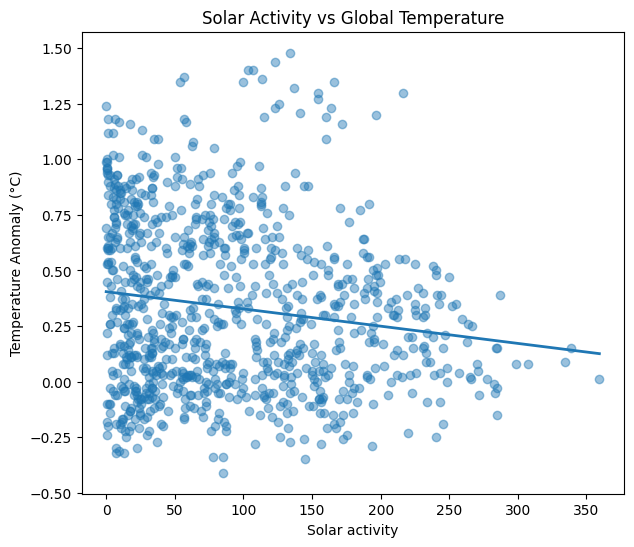

In [63]:
plt.figure(figsize=(7, 6))

plt.scatter(
    data["Sunspot_Number"],
    data["Temperature_Anomaly"],
    alpha=0.45
)
slope, intercept, r_value, p_value, std_err = stats.linregress(
    data["Sunspot_Number"],
    data["Temperature_Anomaly"]
)

x_line = np.linspace(
    data["Sunspot_Number"].min(),
    data["Sunspot_Number"].max(),
    200
)

y_line = (
    intercept +
    slope * x_line
)

plt.plot(
    x_line,
    y_line,
    linewidth=2
)

plt.xlabel("Solar activity")
plt.ylabel("Temperature Anomaly (°C)")
plt.title(
    "Solar Activity vs Global Temperature"
)
plt.show()

#Regression of Detrended Variables

A linear regression is fitted between detrended solar activity and detrended temperature.

The model is:

$$ T_t^{*} = \beta_0+ \beta_1S_t^{*} +\epsilon_t $$

where:

$T_t^{*}$ = detrended temperature,
$S_t^{*}$ = detrended solar activity,
$\beta_1$ = estimated linear relationship.

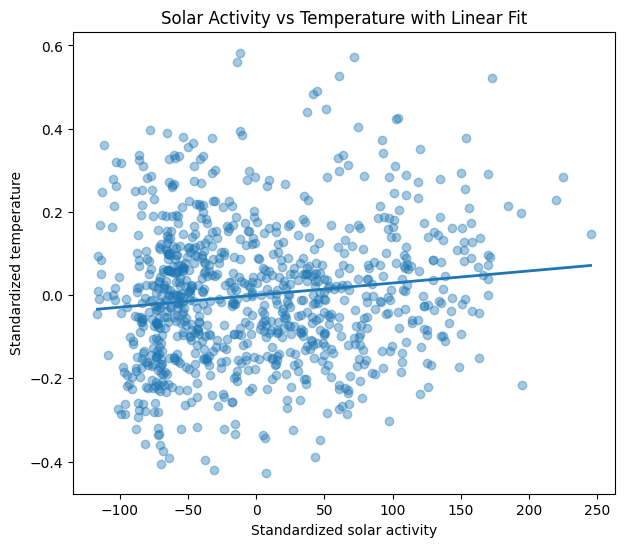

Slope: 0.00029032417554675726
Correlation: 0.12709461127226632
p-value: 0.00013180962933169362


In [38]:
y = detrended["Temperature_Detrended"].values
x = detrended["Sunspot_Detrended"].values

slope, intercept, r_value, p_value, std_err = stats.linregress(
    x,
    y
)

x_line = np.linspace(
    x.min(),
    x.max(),
    100
)

y_line = (
    intercept +
    slope * x_line
)

plt.figure(figsize=(7, 6))

plt.scatter(
    x,
    y,
    alpha=0.4
)

plt.plot(
    x_line,
    y_line,
    linewidth=2
)

plt.xlabel("Standardized solar activity")
plt.ylabel("Standardized temperature")
plt.title(
    "Solar Activity vs Temperature with Linear Fit"
)


plt.show()

print("Slope:", slope)
print("Correlation:", r_value)
print("p-value:", p_value)

#Autocorrelation-Adjusted Statistical Significance

The effective sample size is approximated using lag-1 autocorrelation:

$$ N_{\text{eff}} = N \frac{1-r_xr_y} {1+r_xr_y} $$

where:

$r_x$ = lag-1 autocorrelation of solar activity,

$r_y$ = lag-1 autocorrelation of temperature.

In [40]:
def effective_sample_size(x, y):

    x = pd.Series(x).dropna().values
    y = pd.Series(y).dropna().values

    n = min(len(x), len(y))

    x = x[:n]
    y = y[:n]

    rx1 = np.corrcoef(
        x[:-1],
        x[1:]
    )[0, 1]

    ry1 = np.corrcoef(
        y[:-1],
        y[1:]
    )[0, 1]

    neff = n * (
        (1 - rx1 * ry1) /
        (1 + rx1 * ry1)
    )

    neff = max(
        3,
        min(n, neff)
    )

    return neff, rx1, ry1


def autocorrelation_adjusted_pvalue(r, n_eff):


    if abs(r) >= 1:
        return 0.0

    t_value = (
        r *
        np.sqrt(
            (n_eff - 2) /
            (1 - r**2)
        )
    )

    p_value = 2 * stats.t.sf(
        abs(t_value),
        df=n_eff - 2
    )

    return p_value


x = detrended["Sunspot_Detrended"].values
y = detrended["Temperature_Detrended"].values

n_eff, rx1, ry1 = effective_sample_size(
    x,
    y
)

p_adjusted = autocorrelation_adjusted_pvalue(
    r_detrended,
    n_eff
)

print("AUTOCORRELATION-ADJUSTED SIGNIFICANCE")


print(f"\nObserved N               = {len(x)}")
print(f"Effective N              = {n_eff:.2f}")
print(f"Sunspot lag-1 AC         = {rx1:.4f}")
print(f"Temperature lag-1 AC     = {ry1:.4f}")
print(f"Detrended correlation    = {r_detrended:.6f}")
print(f"Adjusted p-value         = {p_adjusted:.6e}")

AUTOCORRELATION-ADJUSTED SIGNIFICANCE

Observed N               = 900
Effective N              = 166.57
Sunspot lag-1 AC         = 0.9378
Temperature lag-1 AC     = 0.7333
Detrended correlation    = 0.127095
Adjusted p-value         = 1.021337e-01


#Calculating Lagged Correlations

In [41]:
lags = range(-120, 121)

lag_correlations = []

for lag in lags:

    shifted_solar = (
        data["Sunspot_Detrended"]
        .shift(lag)
    )

    temp_series = data["Temperature_Detrended"]

    valid = pd.concat(
        [shifted_solar, temp_series],
        axis=1
    ).dropna()

    if len(valid) > 10:

        r = valid.iloc[:, 0].corr(
            valid.iloc[:, 1]
        )

    else:

        r = np.nan

    lag_correlations.append(r)

lag_results = pd.DataFrame({
    "Lag_Months": list(lags),
    "Correlation": lag_correlations
})

display(lag_results.head())

,Lag_Months,Correlation
0,-120,0.053587
1,-119,0.060371
2,-118,0.058471
3,-117,0.068384
4,-116,0.071236


#Identifying the Maximum Absolute Lagged Correlation

In [42]:
valid_lags = lag_results.dropna()

strongest = valid_lags.loc[
    valid_lags["Correlation"].abs().idxmax()
]

print(
    "Lag with strongest absolute correlation:"
)

print(
    "Lag:",
    strongest["Lag_Months"],
    "months"
)

print(
    "Correlation:",
    strongest["Correlation"]
)

Lag with strongest absolute correlation:
Lag: 69.0 months
Correlation: -0.17787771606247108


#Plotting Lagged Correlation

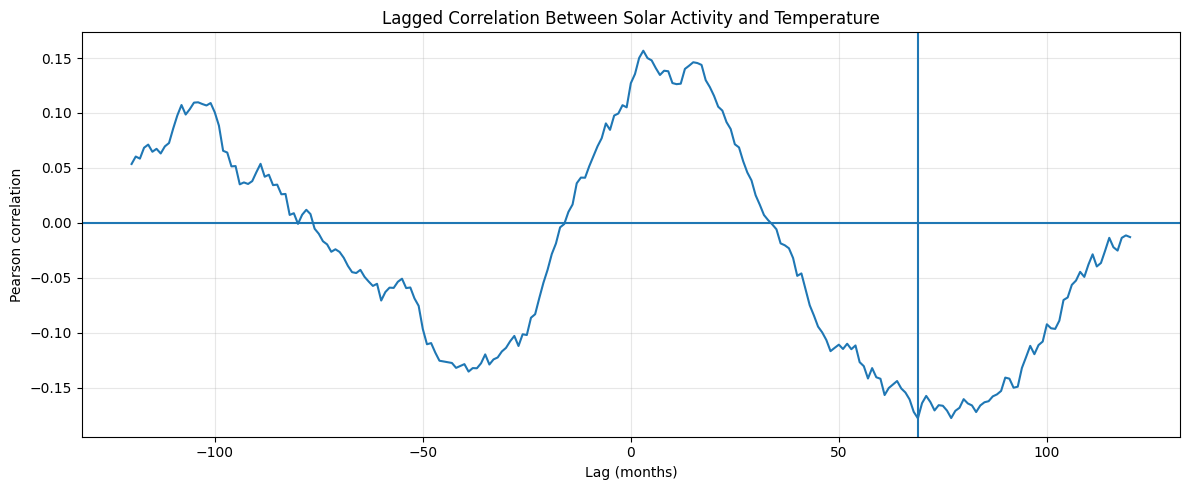

Strongest lag: 69.0 months
Correlation: -0.17787771606247108


In [43]:
strongest = lag_results.loc[
    lag_results["Correlation"].abs().idxmax()
]

strongest_lag = strongest["Lag_Months"]
strongest_r = strongest["Correlation"]

plt.figure(figsize=(12, 5))

plt.plot(
    lag_results["Lag_Months"],
    lag_results["Correlation"]
)

plt.axhline(0)

plt.axvline(
    strongest_lag
)

plt.xlabel("Lag (months)")
plt.ylabel("Pearson correlation")
plt.title("Lagged Correlation Between Solar Activity and Temperature")

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("Strongest lag:", strongest_lag, "months")
print("Correlation:", strongest_r)

#Fourier Spectral Analysis of Solar Activity

If \(f\) is frequency, the corresponding period is:

$$ P=\frac{1}{f} $$

Because the data are monthly:

$$ P_{\text{months}}=\frac{1}{f} $$

and:

$$P_{years} = \frac{1}{12f}$$
	​


In [44]:
solar_series = (
    data["Sunspot_Z"]
    .dropna()
    .values
)

frequency, power = periodogram(
    solar_series
)

valid = frequency > 0

frequency = frequency[valid]
power = power[valid]

period_months = 1 / frequency
period_years = period_months / 12

#Plotting the Solar Power Spectrum

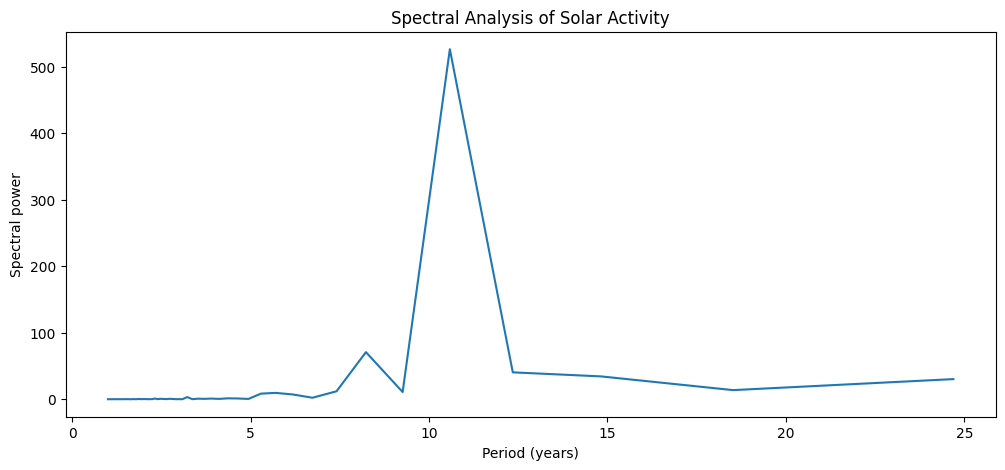

In [45]:
mask = (
    (period_years >= 1) &
    (period_years <= 30)
)

plt.figure(figsize=(12, 5))

plt.plot(
    period_years[mask],
    power[mask]
)

plt.xlabel("Period (years)")
plt.ylabel("Spectral power")
plt.title(
    "Spectral Analysis of Solar Activity"
)


plt.show()

#Ranking Dominant Solar Periodicities

In [46]:
spectrum = pd.DataFrame({
    "Period_Years": period_years,
    "Power": power
})

spectrum = spectrum[
    (spectrum["Period_Years"] >= 1) &
    (spectrum["Period_Years"] <= 30)
]

dominant = spectrum.sort_values(
    "Power",
    ascending=False
).head(10)

display(dominant)

,Period_Years,Power
6,10.583333,526.155610
8,8.231481,70.791359
5,12.347222,40.399384
4,14.816667,34.323251
2,24.694444,30.236414
3,18.520833,13.695075
9,7.408333,11.955720
7,9.260417,10.800065
12,5.698718,9.519954
13,5.291667,8.420567


#Uploading NOAA Niño 3.4 Dataset

In [47]:
print(
    "Upload the NOAA Niño 3.4 monthly CSV/TXT file."
)

enso_upload = files.upload()

for filename in enso_upload.keys():
    print("-", filename)

Upload the NOAA Niño 3.4 monthly CSV/TXT file.


Saving nino34.long.anom.csv to nino34.long.anom.csv
- nino34.long.anom.csv


#Inspecting the NOAA Niño 3.4 Dataset

In [48]:
for filename in enso_upload.keys():

    enso_file = "/content/" + filename

    enso_raw = pd.read_csv(
        enso_file,
        comment="#"
    )

    print("Filename:", filename)
    print("Columns:", enso_raw.columns.tolist())

    display(enso_raw.head(10))

Filename: nino34.long.anom.csv
Columns: ['Date', '   NINA34  missing value -99.99 https://psl.noaa.gov/data/timeseries/month/']


,Date,NINA34 missing value -99.99 https://psl.noaa.gov/data/timeseries/month/
0,1870-01-01,-1.00
1,1870-02-01,-1.20
2,1870-03-01,-0.83
3,1870-04-01,-0.81
4,1870-05-01,-1.27
5,1870-06-01,-1.08
6,1870-07-01,-1.04
7,1870-08-01,-0.88
8,1870-09-01,-0.53
9,1870-10-01,-0.92


#Cleaning and Preparing ENSO Data

In [49]:
enso_raw = enso_raw.rename(
    columns={
        "   NINA34  missing value -99.99 https://psl.noaa.gov/data/timeseries/month/": "ENSO"
    }
)

print(enso_raw.columns.tolist())
enso = enso_raw.copy()

enso["Date"] = pd.to_datetime(enso["Date"], errors="coerce")

enso["ENSO"] = pd.to_numeric(
    enso["ENSO"],
    errors="coerce"
)

enso = (
    enso[["Date", "ENSO"]]
    .dropna()
    .sort_values("Date")
    .reset_index(drop=True)
)

display(enso.head(15))

['Date', 'ENSO']


,Date,ENSO
0,1870-01-01,-1.00
1,1870-02-01,-1.20
2,1870-03-01,-0.83
3,1870-04-01,-0.81
4,1870-05-01,-1.27
5,1870-06-01,-1.08
6,1870-07-01,-1.04
7,1870-08-01,-0.88
8,1870-09-01,-0.53
9,1870-10-01,-0.92


#Merging ENSO with Solar and Temperature Data

In [50]:
data = data.drop(
    columns=[col for col in data.columns if col.startswith("ENSO")],
    errors="ignore"
)

data = pd.merge(
    data,
    enso[["Date", "ENSO"]],
    on="Date",
    how="inner"
)

data = (
    data
    .sort_values("Date")
    .reset_index(drop=True)
)

print("Final columns:")
print(data.columns.tolist())

print("\nFinal date range:")
print(data["Date"].min(), "→", data["Date"].max())

display(data.head(15))

Final columns:
['Date', 'Sunspot_Number', 'Temperature_Anomaly', 'Month', 'Temperature_Deseasonalized', 'Sunspot_Detrended', 'Temperature_Detrended', 'Sunspot_12M', 'Temperature_12M', 'Sunspot_Z', 'Temperature_Z', 'ENSO']

Final date range:
1950-01-01 00:00:00 → 2024-12-01 00:00:00


,Date,Sunspot_Number,Temperature_Anomaly,Month,Temperature_Deseasonalized,Sunspot_Detrended,Temperature_Detrended,Sunspot_12M,Temperature_12M,Sunspot_Z,Temperature_Z,ENSO
0,1950-01-01,143.9,-0.26,1,-0.604933,23.852394,-0.000879,NaN,NaN,NaN,NaN,-1.05
1,1950-02-01,134.3,-0.27,2,-0.625600,14.317256,-0.012199,NaN,NaN,NaN,NaN,-1.50
2,1950-03-01,155.4,-0.08,3,-0.461467,35.482118,0.176481,NaN,NaN,NaN,NaN,-1.07
3,1950-04-01,160.6,-0.21,4,-0.544933,40.746981,0.045161,NaN,NaN,NaN,NaN,-0.91
4,1950-05-01,150.5,-0.11,5,-0.427467,30.711843,0.143842,NaN,NaN,NaN,NaN,-1.30
5,1950-06-01,118.3,-0.05,6,-0.366133,-1.423295,0.202522,NaN,NaN,NaN,NaN,-0.86
6,1950-07-01,128.9,-0.09,7,-0.406400,9.241567,0.161202,NaN,NaN,NaN,NaN,-1.08
7,1950-08-01,120.6,-0.16,8,-0.482667,1.006430,0.089882,NaN,NaN,NaN,NaN,-0.63
8,1950-09-01,72.7,-0.11,9,-0.432267,-46.828708,0.138562,NaN,NaN,NaN,NaN,-1.10
9,1950-10-01,87.0,-0.20,10,-0.536000,-32.463846,0.047242,NaN,NaN,NaN,NaN,-0.83


#Final Dataset Quality Check

In [51]:
print(data.columns.tolist())
print(data.shape)
print(data.isna().sum())

['Date', 'Sunspot_Number', 'Temperature_Anomaly', 'Month', 'Temperature_Deseasonalized', 'Sunspot_Detrended', 'Temperature_Detrended', 'Sunspot_12M', 'Temperature_12M', 'Sunspot_Z', 'Temperature_Z', 'ENSO']
(900, 12)
Date                           0
Sunspot_Number                 0
Temperature_Anomaly            0
Month                          0
Temperature_Deseasonalized     0
Sunspot_Detrended              0
Temperature_Detrended          0
Sunspot_12M                   11
Temperature_12M               11
Sunspot_Z                     11
Temperature_Z                 11
ENSO                           0
dtype: int64


In [52]:
print("Final columns:")
print(data.columns.tolist())

print(
    "\nDate range:",
    data["Date"].min(),
    "to",
    data["Date"].max()
)

display(data.head(15))

Final columns:
['Date', 'Sunspot_Number', 'Temperature_Anomaly', 'Month', 'Temperature_Deseasonalized', 'Sunspot_Detrended', 'Temperature_Detrended', 'Sunspot_12M', 'Temperature_12M', 'Sunspot_Z', 'Temperature_Z', 'ENSO']

Date range: 1950-01-01 00:00:00 to 2024-12-01 00:00:00


,Date,Sunspot_Number,Temperature_Anomaly,Month,Temperature_Deseasonalized,Sunspot_Detrended,Temperature_Detrended,Sunspot_12M,Temperature_12M,Sunspot_Z,Temperature_Z,ENSO
0,1950-01-01,143.9,-0.26,1,-0.604933,23.852394,-0.000879,NaN,NaN,NaN,NaN,-1.05
1,1950-02-01,134.3,-0.27,2,-0.625600,14.317256,-0.012199,NaN,NaN,NaN,NaN,-1.50
2,1950-03-01,155.4,-0.08,3,-0.461467,35.482118,0.176481,NaN,NaN,NaN,NaN,-1.07
3,1950-04-01,160.6,-0.21,4,-0.544933,40.746981,0.045161,NaN,NaN,NaN,NaN,-0.91
4,1950-05-01,150.5,-0.11,5,-0.427467,30.711843,0.143842,NaN,NaN,NaN,NaN,-1.30
5,1950-06-01,118.3,-0.05,6,-0.366133,-1.423295,0.202522,NaN,NaN,NaN,NaN,-0.86
6,1950-07-01,128.9,-0.09,7,-0.406400,9.241567,0.161202,NaN,NaN,NaN,NaN,-1.08
7,1950-08-01,120.6,-0.16,8,-0.482667,1.006430,0.089882,NaN,NaN,NaN,NaN,-0.63
8,1950-09-01,72.7,-0.11,9,-0.432267,-46.828708,0.138562,NaN,NaN,NaN,NaN,-1.10
9,1950-10-01,87.0,-0.20,10,-0.536000,-32.463846,0.047242,NaN,NaN,NaN,NaN,-0.83


#Standardizing the ENSO Index

The ENSO Z-score is calculated by:

$$ Z_{\text{ENSO}} = \frac{ENSO-\overline{ENSO}} {S_{ENSO}} $$


In [53]:
data["ENSO"] = pd.to_numeric(
    data["ENSO"],
    errors="coerce"
)


enso_mean = data["ENSO"].mean(skipna=True)
enso_std = data["ENSO"].std(skipna=True)

data["ENSO_Z"] = (
    data["ENSO"] - enso_mean
) / enso_std


display(
    data[
        [
            "Date",
            "Sunspot_Z",
            "ENSO_Z",
            "Temperature_Z"
        ]
    ].head(15)
)

,Date,Sunspot_Z,ENSO_Z,Temperature_Z
0,1950-01-01,NaN,-1.200107,NaN
1,1950-02-01,NaN,-1.741762,NaN
2,1950-03-01,NaN,-1.224180,NaN
3,1950-04-01,NaN,-1.031592,NaN
4,1950-05-01,NaN,-1.501026,NaN
5,1950-06-01,NaN,-0.971408,NaN
6,1950-07-01,NaN,-1.236217,NaN
7,1950-08-01,NaN,-0.694562,NaN
8,1950-09-01,NaN,-1.260291,NaN
9,1950-10-01,NaN,-0.935298,NaN


#Verifying ENSO Standardization

In [54]:
print("ENSO mean:", data["ENSO"].mean())
print("ENSO standard deviation:", data["ENSO"].std())

print("\nENSO_Z mean:", data["ENSO_Z"].mean())
print("ENSO_Z standard deviation:", data["ENSO_Z"].std())

ENSO mean: -0.05296666666666666
ENSO standard deviation: 0.8307871677699754

ENSO_Z mean: -2.3684757858670008e-17
ENSO_Z standard deviation: 0.9999999999999999


In [55]:
print(
    data[
        ["Date", "Temperature_Z", "Sunspot_Z", "ENSO_Z"]
    ].isna().sum()
)


print("\nObservations:", len(data))
print("Start:", data["Date"].min())
print("End:", data["Date"].max())

Date              0
Temperature_Z    11
Sunspot_Z        11
ENSO_Z            0
dtype: int64

Observations: 900
Start: 1950-01-01 00:00:00
End: 2024-12-01 00:00:00


#Plotting Solar Activity, ENSO and Temperature

Because all three variables are expressed as Z-scores, they can be compared visually despite having different original units.

The graph is intended to show the relation between temperature fluctuations, ENSO variability, solar variability.

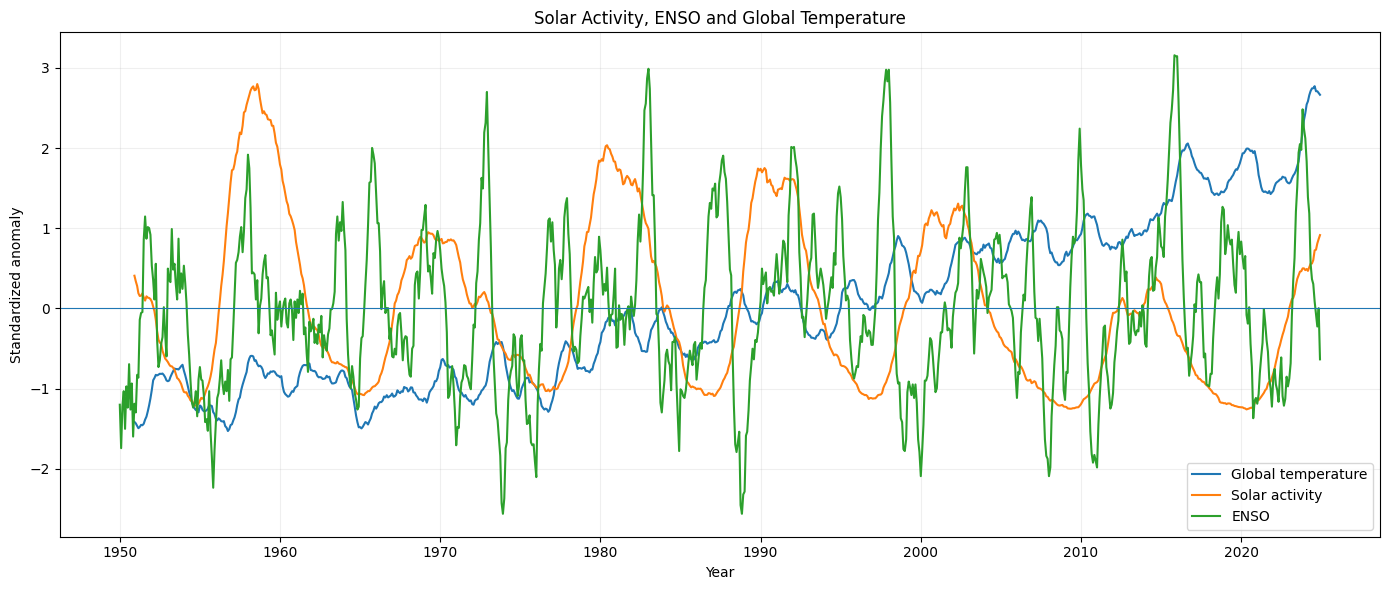

In [56]:
plt.figure(figsize=(14, 6))

plt.plot(
    data["Date"],
    data["Temperature_Z"],
    label="Global temperature"
)

plt.plot(
    data["Date"],
    data["Sunspot_Z"],
    label="Solar activity"
)

plt.plot(
    data["Date"],
    data["ENSO_Z"],
    label="ENSO"
)

plt.axhline(
    0,
    linewidth=0.8
)

plt.xlabel("Year")
plt.ylabel("Standardized anomaly")
plt.title(
    "Solar Activity, ENSO and Global Temperature"
)

plt.legend()
plt.grid(alpha=0.2)

plt.tight_layout()

plt.savefig(
    "figures/10_solar_enso_temperature.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

#End of Analysis

##Workflow of the current project

The analysis has progressed from data acquisition and preprocessing to:

Time-series construction

1. Solar-temperature alignment
2. Seasonal adjustment
3. Trend removal
4. Pearson correlation
5. Moving-average smoothing
6. Standardization
7. Linear regression
8. Autocorrelation-adjusted significance testing
9. Lagged correlation analysis
10. Spectral analysis
11. ENSO integration
12. Combined climate-variable visualization

#Conclusion


This study investigates the relation between the sunspot activity and the global temperature anomalies in the period range of 1950–2024. The Pearson coefficient (r) in the initial stage produced a small negative coefficient, indicating the weak linear association between the sunspot activity and the temperature anomalies.


With applied seasonal adjustment and detrending, the data were processed to avoid the long-term seasonal pattern and trends.


Standardizing and smoothing the temperature and solar activity exhibit a very weak correspondence in the current study period, and the spectral analysis identified the periodic behaviour in the solar activity.


The NOAA Niño 3.4 index is added afterwards to correspond to the temperature fluctuation due to climate variability such as ENSO.

Overall, the result shows that the observed solar activity and temperature anomaly are considerably weak and contribute as a very small component in the modern long-term global warming trend. Hence, this study supports the correlation between solar variability and temperature variability, but the statistical result does not demonstrate a very strong influence over the temperature change.
